In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("weather.csv.gz")

In [34]:
df["date"] = pd.to_datetime(df["date"])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df

,date,stn,Station Name,CTRY_ISO,wban,temp,prcp,wdsp,visib,slp,sndp,dewp,mxpsd,month,year
0,2020-01-01,910660,HENDERSON FIELD AIRPORT,UM,22701,62.2,0.01,9.0,10.0,1023.4,NaN,47.3,14.0,1,2020
1,2020-01-01,720699,CARROLL CO RGNL/JJACK B POAGE FIELD AIRPORT,US,3724,41.3,0.00,9.8,10.0,NaN,NaN,25.6,14.0,1,2020
2,2020-01-01,476000,WAJIMA,JP,99999,39.7,0.55,6.2,11.1,1024.5,NaN,34.8,9.9,1,2020
3,2020-01-01,998015,WELLS RESERVE,US,99999,34.4,0.00,5.6,NaN,NaN,NaN,28.1,8.9,1,2020
4,2020-01-01,999999,NaN,NaN,126,39.0,0.00,2.2,NaN,NaN,NaN,28.7,14.0,1,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16241440,2023-12-31,727454,GRAND MARAIS/COOK CO ARPT,US,4911,16.7,NaN,8.7,7.1,NaN,NaN,13.3,17.1,12,2023
16241441,2023-12-31,477880,HOFU,JP,99999,49.2,NaN,9.4,5.8,NaN,NaN,39.5,20.0,12,2023
16241442,2023-12-31,997799,SISTERS ISLAND,US,99999,38.4,0.00,6.3,NaN,NaN,NaN,30.7,15.0,12,2023
16241443,2023-12-31,560460,DARLAG,CN,99999,14.6,0.00,1.9,11.7,1033.0,NaN,-12.6,3.9,12,2023


In [35]:
NO = df[df["Station Name"]=="OLSZTYN"]

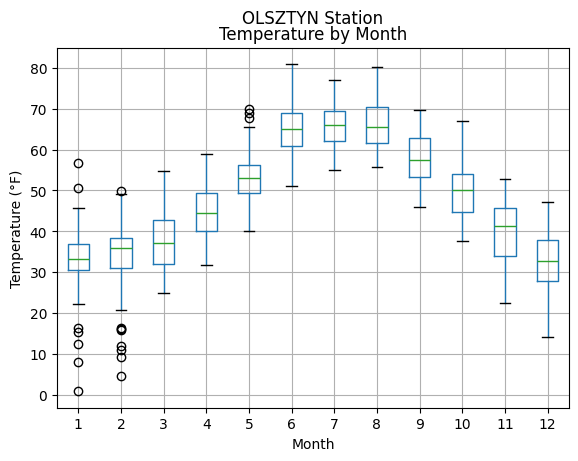

In [36]:
NO.boxplot("temp", by="month")
plt.title("Temperature by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Temperature (°F)")
plt.show()

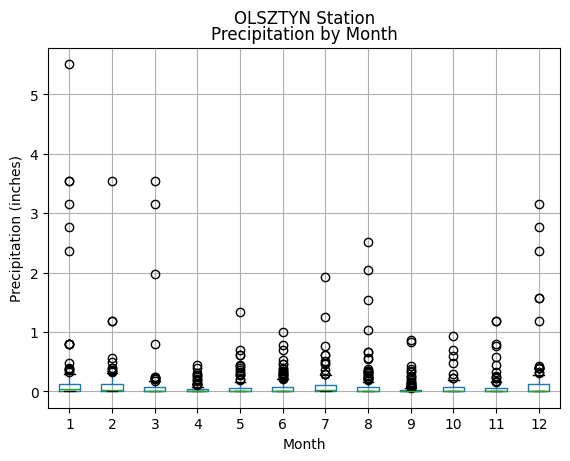

In [37]:
NO.boxplot("prcp", by="month")
plt.title("Precipitation by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Precipitation (inches)")
plt.show()

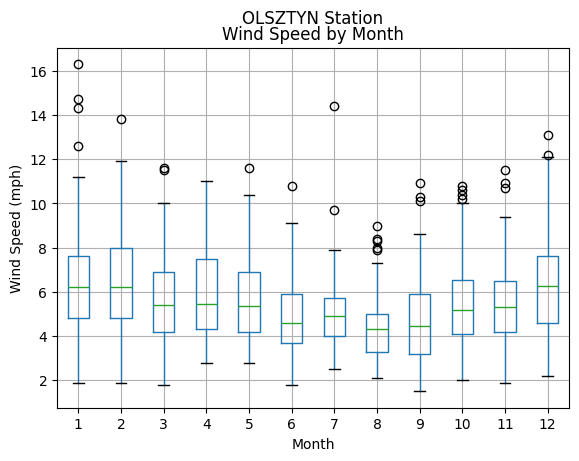

In [38]:
NO.boxplot("wdsp", by="month")
plt.title("Wind Speed by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Wind Speed (mph)")
plt.show()

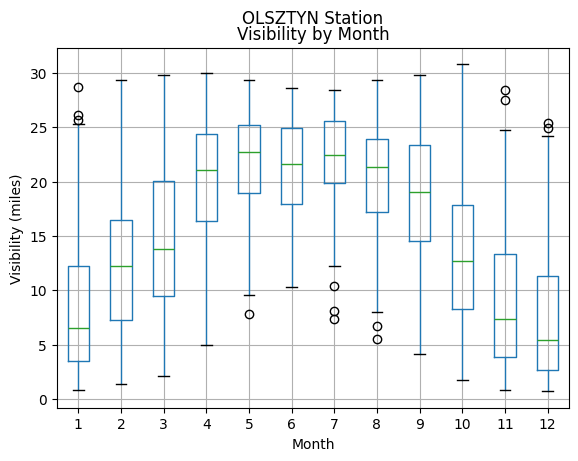

In [39]:
NO.boxplot("visib", by="month")
plt.title("Visibility by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Visibility (miles)")
plt.show()

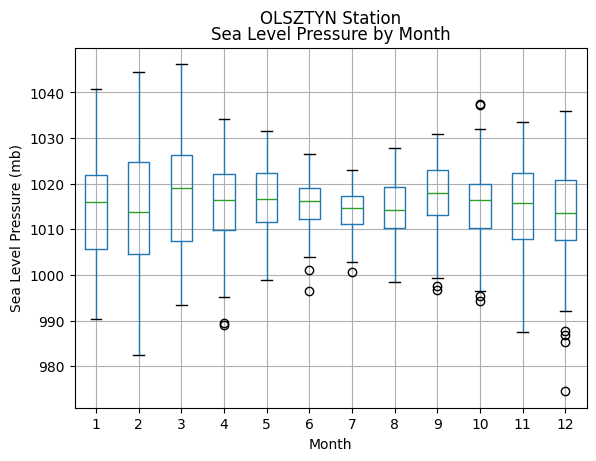

In [40]:
NO.boxplot("slp", by="month")
plt.title("Sea Level Pressure by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Sea Level Pressure (mb)")
plt.show()

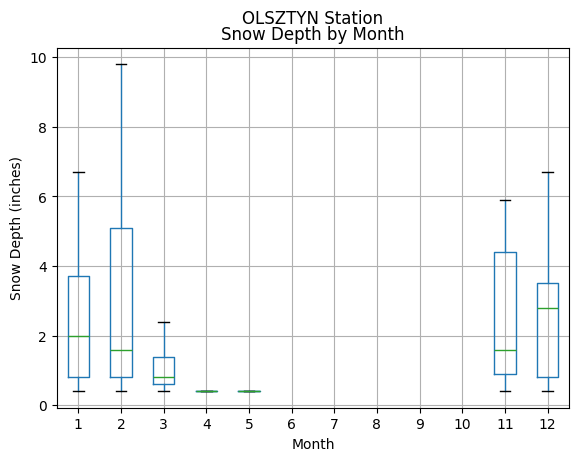

In [41]:
NO.boxplot("sndp", by="month")
plt.title("Snow Depth by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Snow Depth (inches)")
plt.show()

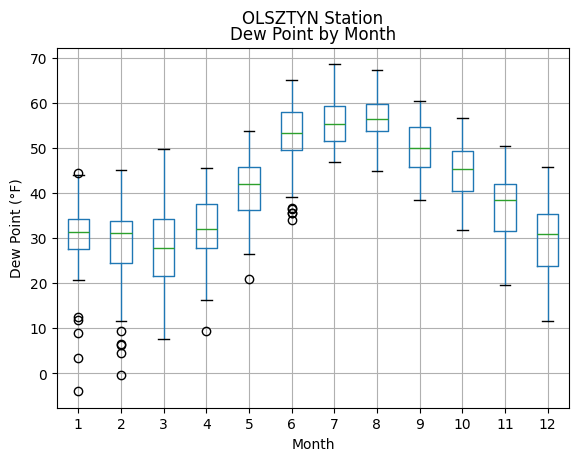

In [42]:
NO.boxplot("dewp", by="month")
plt.title("Dew Point by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Dew Point (°F)")
plt.show()

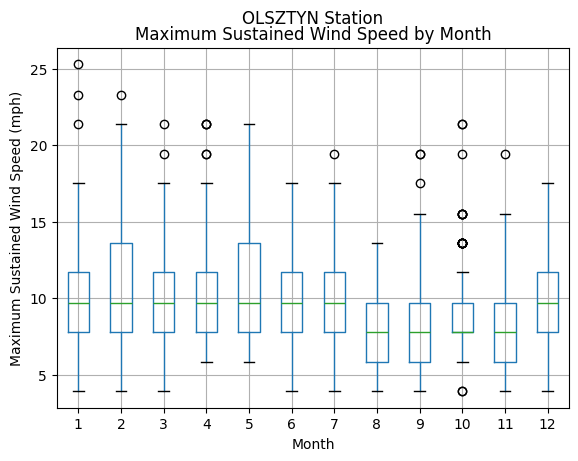

In [43]:
NO.boxplot("mxpsd", by="month")
plt.title("Maximum Sustained Wind Speed by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Maximum Sustained Wind Speed (mph)")
plt.show()

In [44]:
NO[["prcp", "wdsp", "visib", "slp", "sndp", "dewp", "mxpsd"]].describe()

,prcp,wdsp,visib,slp,sndp,dewp,mxpsd
count,1387.000000,1459.000000,1459.000000,1459.000000,100.000000,1457.000000,1459.000000
mean,0.109769,5.541124,15.848938,1015.362029,2.526000,40.623885,9.517204
std,0.367385,2.082294,7.840762,9.284051,2.199202,12.650907,3.228187
min,0.000000,1.500000,0.700000,974.500000,0.400000,-4.000000,3.900000
25%,0.000000,4.000000,9.500000,1009.800000,0.800000,31.200000,7.800000
50%,0.000000,5.200000,16.700000,1015.900000,1.600000,40.300000,9.700000
75%,0.080000,6.700000,22.600000,1021.300000,3.500000,50.800000,11.700000
max,5.510000,16.300000,30.800000,1046.200000,9.800000,68.600000,25.300000


3. 1. Zidentyfikuj brakujące wartości w zbiorze, sprawdź liczbę braków w poszczególnych kolumnach oraz określ ich udział procentowy,

In [45]:
weather_cols = ['temp', 'prcp', 'wdsp', 'visib', 'slp', 'sndp', 'dewp', 'mxpsd']

nan_count = df[weather_cols].isna().sum()
nan_percent = df[weather_cols].isna().mean() * 100

nan_summary = pd.DataFrame({
    'NaN_count': nan_count,
    'NaN_percent': nan_percent
})

nan_summary

,NaN_count,NaN_percent
temp,0,0.000000
prcp,1248231,7.685468
wdsp,611841,3.767159
visib,4271191,26.298097
slp,5614099,34.566499
sndp,15125940,93.131738
dewp,764878,4.709421
mxpsd,833144,5.129741


3. 2. Sprawdź, czy w zbiorze występują wartości liczbowe oznaczające brak danych i w razie potrzeby zamień je na wartości brakujące,

In [46]:
max_value = df[weather_cols].max()
isna_value = df[weather_cols].isna().sum()
nan_summary = pd.DataFrame({
    'Max_value': max_value,
    'NaN_count': isna_value
})
nan_summary

,Max_value,NaN_count
temp,110.00,0
prcp,19.29,1248231
wdsp,84.90,611841
visib,90.00,4271191
slp,1077.70,5614099
sndp,117.70,15125940
dewp,90.00,764878
mxpsd,96.90,833144


3. 3. Wybierz co najmniej dwie zmienne pogodowe i uzupełnij brakujące wartości stosując różne metody imputacji: średnia, mediana, interpolacja w czasie, 

In [47]:
new_df = df[(df['date'] >= '2020-01-01') & (df['date'] <= '2020-12-31')].copy()
new_df['date'] = pd.to_datetime(new_df['date'])
new_df = new_df.set_index('date')
new_df = new_df.sort_index()

temp_mean = new_df['temp'].fillna(new_df['temp'].mean())
temp_median = new_df['temp'].fillna(new_df['temp'].median())
temp_interp = new_df['temp'].interpolate(method='time')

prcp_mean = new_df['prcp'].fillna(new_df['prcp'].mean())
prcp_median = new_df['prcp'].fillna(new_df['prcp'].median())
prcp_interp = new_df['prcp'].interpolate(method='time')

3. 4. Porównaj otrzymane wyniki dla różnych metod imputacji i uzasadnij wybór metody, którą uznasz za najbardziej odpowiednią. 

In [48]:
new_df.isna().sum()

stn                   0
Station Name      13119
CTRY_ISO          43727
wban                  0
temp                  0
prcp             306725
wdsp             163485
visib           1110895
slp             1418634
sndp            3863012
dewp             202421
mxpsd            236606
month                 0
year                  0
dtype: int64

In [57]:
df_month = df[(df['date'].dt.year == 2020) & (df['date'].dt.month == 7)]

stations = df_month['Station Name'].dropna().unique()[:10]
df_selected = df_month[df_month['Station Name'].isin(stations)]

stats = df_selected.groupby('Station Name')[['temp','prcp','wdsp']].describe()

stats

temp                                            \
                           count       mean       std   min     25%    50%   
Station Name                                                                 
BAIYUN INTL                 31.0  88.490323  2.711870  81.7  87.550  88.90   
CASA GRANDE MUNICIPAL ARPT  30.0  95.846667  4.924095  85.5  94.650  96.35   
CHARLES CITY MUNICIPAL APT  30.0  74.473333  4.735481  63.5  71.125  75.10   
CHEROKEE COUNTY AIRPORT     62.0  80.016129  2.800772  71.9  78.025  80.10   
JONESBORO MUNICIPAL ARPT    28.0  82.817857  2.194109  78.7  81.475  82.60   
LUMPARLAND LANGNAS HARBOUR  31.0  61.158065  3.459265  53.8  59.250  60.50   
LUQA                        31.0  79.967742  2.691640  76.5  77.350  79.40   
OCEAN COUNTY AIRPORT        31.0  78.135484  4.059109  69.7  75.000  78.40   
ROGNSUNDET                  31.0  53.987097  7.216866  43.0  48.050  52.80   
SMITHERS                    31.0  58.516129  3.559784  51.7  56.550  57.70   

                                          prcp            ...               \
                              75%    max count      mean  ...    75%   max   
Station Name                                              ...                
BAIYUN INTL                 90.35   92.3  31.0  0.085484  ...  0.050  0.73   
CASA GRANDE MUNICIPAL ARPT  97.80  106.7  30.0  0.000000  ...  0.000  0.00   
CHARLES CITY MUNICIPAL APT  78.60   80.7  29.0  0.051724  ...  0.000  0.96   
CHEROKEE COUNTY AIRPORT     82.35   86.1  38.0  0.000000  ...  0.000  0.00   
JONESBORO MUNICIPAL ARPT    83.85   87.4  28.0  0.069286  ...  0.005  0.72   
LUMPARLAND LANGNAS HARBOUR  63.45   68.6  31.0  0.061613  ...  0.040  0.79   
LUQA                        82.05   86.2  31.0  0.000000  ...  0.000  0.00   
OCEAN COUNTY AIRPORT        80.75   86.3  29.0  0.127241  ...  0.040  2.12   
ROGNSUNDET                  57.70   67.8  31.0  0.000000  ...  0.000  0.00   
SMITHERS                    60.30   69.0  31.0  0.074516  ...  0.085  0.44   

                            wdsp                                          \
                           count       mean       std  min    25%    50%   
Station Name                                                               
BAIYUN INTL                 31.0   6.383871  1.815690  3.5  4.650   6.20   
CASA GRANDE MUNICIPAL ARPT  30.0   6.216667  1.521588  3.6  5.225   6.10   
CHARLES CITY MUNICIPAL APT  30.0   6.230000  2.427025  2.2  3.775   6.60   
CHEROKEE COUNTY AIRPORT     62.0   2.741935  1.644917  0.3  1.500   2.45   
JONESBORO MUNICIPAL ARPT    27.0   5.566667  2.134335  2.0  4.450   5.40   
LUMPARLAND LANGNAS HARBOUR  30.0   9.303333  2.518413  4.3  7.625   8.75   
LUQA                        31.0   6.796774  2.652984  4.1  4.850   6.10   
OCEAN COUNTY AIRPORT        31.0   4.845161  1.552598  1.9  3.850   4.70   
ROGNSUNDET                  31.0  10.648387  3.615049  4.9  8.050  10.10   
SMITHERS                    31.0   3.790323  1.365859  1.9  2.800   3.60   

                                          
                               75%   max  
Station Name                              
BAIYUN INTL                  7.850   9.6  
CASA GRANDE MUNICIPAL ARPT   6.725  10.2  
CHARLES CITY MUNICIPAL APT   7.800  11.7  
CHEROKEE COUNTY AIRPORT      3.800   7.2  
JONESBORO MUNICIPAL ARPT     6.800  11.6  
LUMPARLAND LANGNAS HARBOUR  10.450  15.5  
LUQA                         7.800  13.9  
OCEAN COUNTY AIRPORT         5.700   7.8  
ROGNSUNDET                  12.800  18.3  
SMITHERS                     4.550   7.0  

[10 rows x 24 columns]

In [58]:
df_selected = df_month[df_month['Station Name'].isin(stations)]
df_selected['temp_diff'] = df_selected.groupby('Station Name')['temp'].diff()
df_selected['prcp_diff'] = df_selected.groupby('Station Name')['prcp'].diff()

mean_changes = df_selected.groupby('Station Name')[['temp_diff','prcp_diff']].mean()

mean_changes

C:\Users\Adrian\AppData\Local\Temp\ipykernel_19136\1052372273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['temp_diff'] = df_selected.groupby('Station Name')['temp'].diff()
C:\Users\Adrian\AppData\Local\Temp\ipykernel_19136\1052372273.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['prcp_diff'] = df_selected.groupby('Station Name')['prcp'].diff()


,temp_diff,prcp_diff
Station Name,,
BAIYUN INTL,-0.016667,6.000000e-03
CASA GRANDE MUNICIPAL ARPT,0.700000,0.000000e+00
CHARLES CITY MUNICIPAL APT,-0.248276,-2.222222e-03
CHEROKEE COUNTY AIRPORT,0.159016,0.000000e+00
JONESBORO MUNICIPAL ARPT,-0.022222,2.555556e-02
LUMPARLAND LANGNAS HARBOUR,0.093333,-1.333333e-03
LUQA,0.176667,0.000000e+00
OCEAN COUNTY AIRPORT,0.166667,6.538462e-03
ROGNSUNDET,0.436667,0.000000e+00


In [59]:
df_selected = df_month[df_month['Station Name'].isin(stations)]
median_values = df_selected.groupby('Station Name')[['temp','prcp','wdsp']].median()
median_values

,temp,prcp,wdsp
Station Name,,,
BAIYUN INTL,88.90,0.0,6.20
CASA GRANDE MUNICIPAL ARPT,96.35,0.0,6.10
CHARLES CITY MUNICIPAL APT,75.10,0.0,6.60
CHEROKEE COUNTY AIRPORT,80.10,0.0,2.45
JONESBORO MUNICIPAL ARPT,82.60,0.0,5.40
LUMPARLAND LANGNAS HARBOUR,60.50,0.0,8.75
LUQA,79.40,0.0,6.10
OCEAN COUNTY AIRPORT,78.40,0.0,4.70
ROGNSUNDET,52.80,0.0,10.10


In [60]:
df_selected = df_month[df_month['Station Name'].isin(stations)]
std_values = df_selected.groupby('Station Name')[['temp','prcp','wdsp']].std().round(2)
std_values

,temp,prcp,wdsp
Station Name,,,
BAIYUN INTL,2.71,0.19,1.82
CASA GRANDE MUNICIPAL ARPT,4.92,0.00,1.52
CHARLES CITY MUNICIPAL APT,4.74,0.19,2.43
CHEROKEE COUNTY AIRPORT,2.80,0.00,1.64
JONESBORO MUNICIPAL ARPT,2.19,0.19,2.13
LUMPARLAND LANGNAS HARBOUR,3.46,0.15,2.52
LUQA,2.69,0.00,2.65
OCEAN COUNTY AIRPORT,4.06,0.40,1.55
ROGNSUNDET,7.22,0.00,3.62


In [61]:
summary_stats = df_selected.groupby('Station Name')[['temp','prcp','wdsp']].agg(['min','mean','max']).round(2)
summary_stats

temp               prcp             wdsp         \
                             min   mean    max  min  mean   max  min   mean   
Station Name                                                                  
BAIYUN INTL                 81.7  88.49   92.3  0.0  0.09  0.73  3.5   6.38   
CASA GRANDE MUNICIPAL ARPT  85.5  95.85  106.7  0.0  0.00  0.00  3.6   6.22   
CHARLES CITY MUNICIPAL APT  63.5  74.47   80.7  0.0  0.05  0.96  2.2   6.23   
CHEROKEE COUNTY AIRPORT     71.9  80.02   86.1  0.0  0.00  0.00  0.3   2.74   
JONESBORO MUNICIPAL ARPT    78.7  82.82   87.4  0.0  0.07  0.72  2.0   5.57   
LUMPARLAND LANGNAS HARBOUR  53.8  61.16   68.6  0.0  0.06  0.79  4.3   9.30   
LUQA                        76.5  79.97   86.2  0.0  0.00  0.00  4.1   6.80   
OCEAN COUNTY AIRPORT        69.7  78.14   86.3  0.0  0.13  2.12  1.9   4.85   
ROGNSUNDET                  43.0  53.99   67.8  0.0  0.00  0.00  4.9  10.65   
SMITHERS                    51.7  58.52   69.0  0.0  0.07  0.44  1.9   3.79   

                                  
                             max  
Station Name                      
BAIYUN INTL                  9.6  
CASA GRANDE MUNICIPAL ARPT  10.2  
CHARLES CITY MUNICIPAL APT  11.7  
CHEROKEE COUNTY AIRPORT      7.2  
JONESBORO MUNICIPAL ARPT    11.6  
LUMPARLAND LANGNAS HARBOUR  15.5  
LUQA                        13.9  
OCEAN COUNTY AIRPORT         7.8  
ROGNSUNDET                  18.3  
SMITHERS                     7.0